# Figure 2

Daily AOD anomaly maps between clean and polluted simulatings, from few days before WAI up to event.

In [2]:
import xarray as xr
import datetime as dt
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors, colormaps
import cartopy.crs as ccrs
import datetime as dt
import pandas as pd
import numpy as np
import string
import utils
from pyproj import Transformer


# Read model output and MOSAiC coordinates

In [12]:
simulations = {
    "NO_BLOW_SNOW": {
        "microphysics": "Thompson",
        "pollution_state": "polluted",
    },
    "NO_BLOW_SNOW_CLEAN": {
        "microphysics": "Thompson",
        "pollution_state": "clean",
    }
}

tslice = slice(dt.datetime(2020,4,13), dt.datetime(2020,4,18))


In [13]:
aod = []
for sim, meta in simulations.items():
    print(sim)
    ds = xr.open_dataset(f"/mnt/data/model_output/{sim}/AOD2D_OUT_2020-04-10_2020-04-19.nc").set_index(Time="XTIME")
    ds = ds.expand_dims({"simulation":[sim]})
    ds = ds.assign_coords({
        "day": ("Time",[T.dt.day for T in ds.Time]),
        "pollution_state": ("simulation",[meta["pollution_state"]]),
        "longitude": (["south_north","west_east"],ds.XLONG.isel(Time=0).values),
        "latitude": (["south_north","west_east"],ds.XLAT.isel(Time=0).values),
    })
    ds = ds.sel(Time=tslice)
    ds = ds.groupby(ds.day).mean(keep_attrs=True)
    aod.append(ds)
aod = xr.concat(aod, dim="simulation")

mosaic = xr.open_dataset("/mnt/data/mosaic/nav/mosaic_coords_2020-04.nc")
mosaic = mosaic.assign_coords({"day": ("time", [T.dt.day for T in mosaic.time])})
mosaic = mosaic.groupby(mosaic.day).mean()
mosaic = mosaic.sel(day=aod.day.values)

aod_anom = aod.isel(simulation=aod.pollution_state=="polluted").squeeze() - aod.isel(simulation=aod.pollution_state=="clean").squeeze()


NO_BLOW_SNOW
NO_BLOW_SNOW_CLEAN


In [14]:
p = xr.open_dataset(f"/mnt/data/model_output/NO_BLOW_SNOW/P_2020-04-10_2020-04-19.nc").set_index(Time="XTIME")
pb = xr.open_dataset(f"/mnt/data/model_output/NO_BLOW_SNOW/PB_2020-04-10_2020-04-19.nc").set_index(Time="XTIME")
p = p.isel(bottom_top=0).P + pb.isel(bottom_top=0).PB
p = p.assign_coords({
    "day": ("Time",[T.dt.day for T in p.Time]),
    "longitude": (["south_north","west_east"],p.XLONG.isel(Time=0).values),
    "latitude": (["south_north","west_east"],p.XLAT.isel(Time=0).values),
})
p = p.sel(Time=tslice)
p = p.groupby(p.day).mean(keep_attrs=True)


In [6]:
psfc = xr.open_dataset(f"/mnt/data/model_output/NO_BLOW_SNOW/PSFC_2020-04-10_2020-04-19.nc").set_index(Time="XTIME")
psfc = psfc.assign_coords({
    "day": ("Time",[T.dt.day for T in psfc.Time]),
    "longitude": (["south_north","west_east"],psfc.XLONG.isel(Time=0).values),
    "latitude": (["south_north","west_east"],psfc.XLAT.isel(Time=0).values),
})
psfc = psfc.groupby(psfc.day).mean(keep_attrs=True)


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/model_output/NO_BLOW_SNOW/PSFC_2020-04-10_2020-04-19.nc'

# Read ERA5 MSLP

In [7]:
era_mslp = xr.open_dataarray("/mnt/data/era5/ERA5_mean_sea_level_pressure_2020_wai_days_1h.nc")
era_mslp = era_mslp.groupby(era_mslp.time.dt.day).mean()
era_mslp


<xarray.DataArray 'msl' (day: 4, latitude: 721, longitude: 1440)> Size: 33MB
array([[[100764.91415298, 100764.91415298, 100764.91415298, ...,
         100764.91415298, 100764.91415298, 100764.91415298],
        [100806.98468508, 100807.16643094, 100807.29728796, ...,
         100806.4830665 , 100806.65754253, 100806.78112971],
        [100846.58347345, 100846.97604451, 100847.28864739, ...,
         100845.6020458 , 100845.92918835, 100846.29268007],
        ...,
        [101243.41465798, 101243.26926129, 101242.81126172, ...,
         101243.97443523, 101243.55278483, 101243.3564993 ],
        [101200.58079326, 101200.23184121, 101199.86107965, ...,
         101201.16964986, 101201.00244366, 101200.8206978 ],
        [101139.06345396, 101139.06345396, 101139.06345396, ...,
         101139.06345396, 101139.06345396, 101139.06345396]],

       [[101004.63694472, 101004.63694472, 101004.63694472, ...,
         101004.63694472, 101004.63694472, 101004.63694472],
        [101006.83243473, 101006.96329175, 101007.19592646, ...,
         101006.31627648, 101006.49802235, 101006.6143397 ],
        [101004.18621498, 101004.52062737, 101004.91319843, ...,
         101003.16116832, 101003.48104104, 101003.82272326],
...
          99285.94629769,  99286.81867783,  99287.74921664],
        [ 99248.17223777,  99248.601158  ,  99248.99372907, ...,
          99246.91455641,  99247.33620681,  99247.77239687],
        [ 99215.4070938 ,  99215.4070938 ,  99215.4070938 , ...,
          99215.4070938 ,  99215.4070938 ,  99215.4070938 ]],

       [[100481.57962424, 100481.57962424, 100481.57962424, ...,
         100481.57962424, 100481.57962424, 100481.57962424],
        [100413.54124341, 100413.60667192, 100413.67937027, ...,
         100413.46854507, 100413.48308474, 100413.51216408],
        [100345.61917994, 100345.77911629, 100345.88816381, ...,
         100345.33565639, 100345.39381507, 100345.48832292],
        ...,
        [ 99722.04185821,  99723.78661848,  99725.47322008, ...,
          99717.30919596,  99718.85040087,  99720.44976446],
        [ 99662.75635808,  99663.57057954,  99664.33391216, ...,
          99660.43728088,  99661.23696268,  99661.98575563],
        [ 99612.68173823,  99612.68173823,  99612.68173823, ...,
          99612.68173823,  99612.68173823,  99612.68173823]]],
      shape=(4, 721, 1440))
Coordinates:
  * day        (day) int64 32B 13 14 15 16
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    units:          Pa
    long_name:      Mean sea level pressure
    standard_name:  air_pressure_at_mean_sea_level

In [8]:
era_xx, era_yy = np.meshgrid(era_mslp.longitude.values, era_mslp.latitude.values)


# Plot

In [9]:
matplotlib.rcParams["font.size"] = 16.0
matplotlib.rcParams["lines.linewidth"] = 2.0
matplotlib.rcParams["axes.linewidth"] = 1.2



In [10]:
# makes contours work near the pole without weird artefacts
transformer = Transformer.from_crs(
    "EPSG:4326",
    ccrs.NorthPolarStereo(central_longitude=-25).proj4_init,
    always_xy=True
)
p_x, p_y = transformer.transform(
    p.longitude.values,
    p.latitude.values
)
era_x, era_y = transformer.transform(era_xx, era_yy)

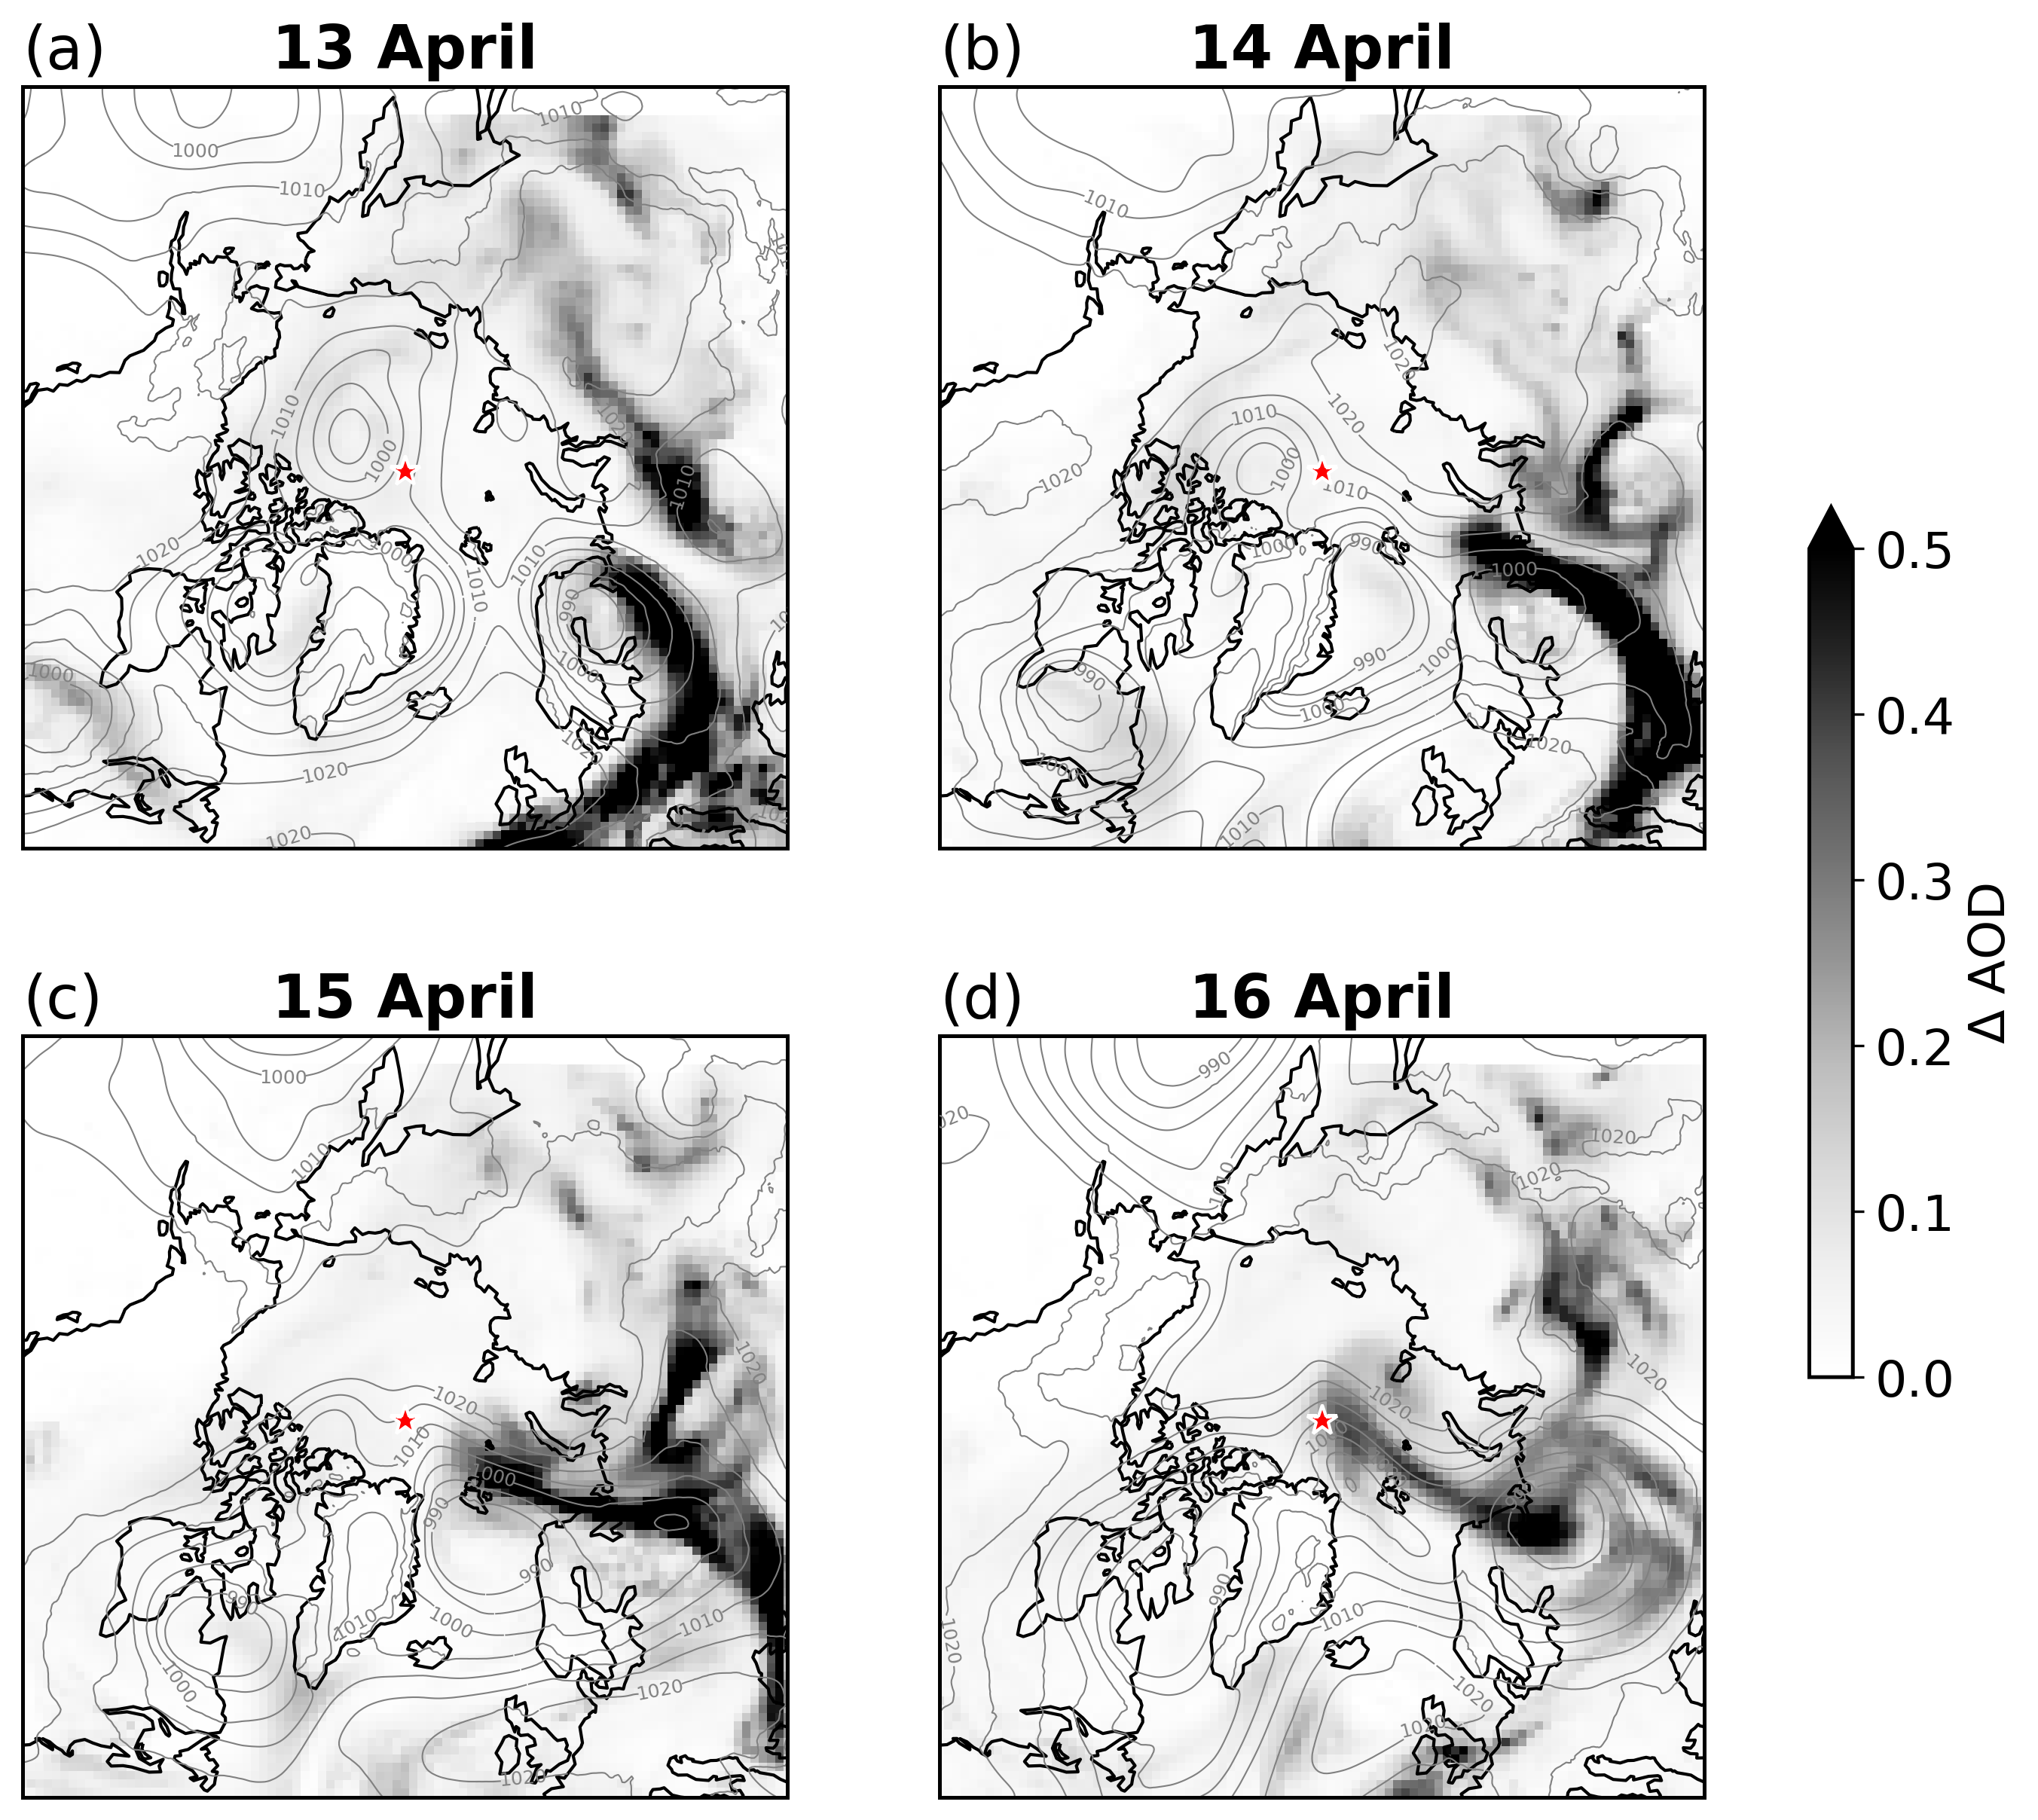

In [16]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10),
    subplot_kw={'projection': ccrs.NorthPolarStereo(central_longitude=-25)},
    dpi=300
)
for ax in axes.flatten():
    ax.coastlines()
for i in range(4):
    ax = axes.flatten()[i]
    day = aod_anom.day.values[i]
    ds = aod_anom.AOD2D_OUT.isel(day=i).squeeze()
    mesh = ax.pcolormesh(
        ds.longitude,
        ds.latitude,
        ds,
        transform=ccrs.PlateCarree(),
        vmin=0, vmax=0.5,
        cmap="Greys",
    )
    ax.plot(
        mosaic.isel(day=i).Longitude,
        mosaic.isel(day=i).Latitude,
        marker="*",
        mec="white",
        mfc="red",
        ms=10,
        zorder=5
    )
    extent = ax.get_extent(crs=ccrs.PlateCarree())
    pressure = ax.contour(
        era_x,
        era_y,
        era_mslp.isel(day=i)/100,
        linewidths=0.5,
        levels=np.arange(990,1025,5),
        colors=["grey"],
    )
    ax.set_extent([-180,180,50,90], crs=ccrs.PlateCarree())
    ax.clabel(pressure, fontsize=6, levels=np.arange(990,1030,10))
    ax.set_title(f"{day} April", weight="bold")
    ax.set_title(f"({string.ascii_lowercase[i]})", loc="left")
plt.colorbar(mesh, ax=axes, label='$\\Delta$ AOD', shrink=0.5, extend="max")
plt.savefig(f"../../figures/figure2_noblowsnow.png", bbox_inches="tight")